# 🔄 Feature Transformation

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand Feature Transformation.
- Learn why feature transformation is required.
- Identify skewed data.
- Apply different transformation techniques.
- Compare distributions before and after transformation.
- Understand when each transformation should be used.

## 📖 Introduction

Feature Transformation is the process of changing the values of features while preserving the underlying information.

Many machine learning algorithms perform better when numerical features follow a more normal distribution or have reduced skewness.

Feature transformation helps improve model accuracy, stability, and training efficiency.

## ❓ What is Feature Transformation?

Feature Transformation modifies the scale or distribution of numerical features.

The goal is to make data easier for machine learning algorithms to learn.

Examples:

Original Salary

10000
15000
500000

After Log Transformation

9.21
9.62
13.12

The transformed data becomes less skewed.

## 💡 Why Feature Transformation?

Feature Transformation helps to:

- Reduce skewness.
- Improve normality.
- Reduce the influence of extreme values.
- Improve algorithm performance.
- Make optimization faster.

## 📚 Types of Feature Transformation

1. Log Transformation
2. Square Root Transformation
3. Reciprocal Transformation
4. Box-Cox Transformation
5. Yeo-Johnson Transformation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\train.csv")

In [3]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

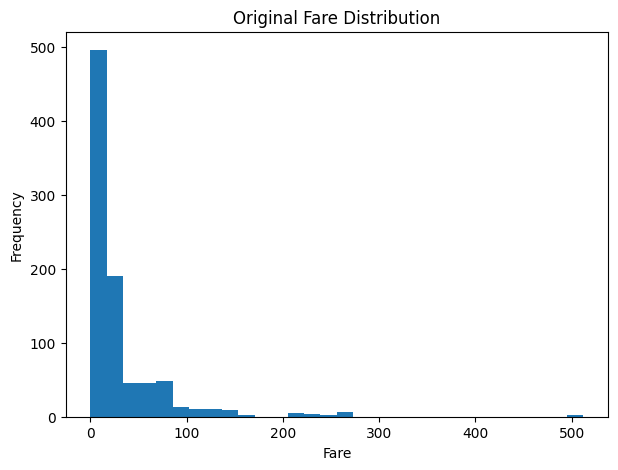

In [4]:
plt.figure(figsize=(7,5))

plt.hist(df["Fare"], bins=30)

plt.title("Original Fare Distribution")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.show()

The Fare distribution is positively skewed.

## 📌 Log Transformation

Log Transformation compresses large values and reduces right-skewed distributions.

Formula:

log(x + 1)

The +1 avoids errors when x = 0.

Apply Log Transformation

In [5]:
df["Fare_Log"] = np.log1p(df["Fare"])

df[["Fare","Fare_Log"]].head()

,Fare,Fare_Log
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


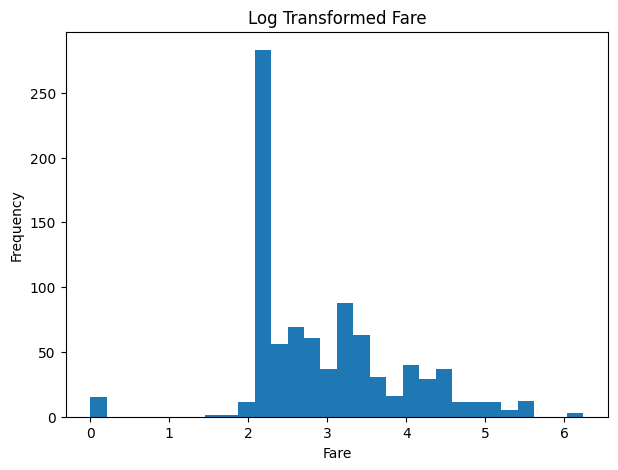

In [7]:
plt.figure(figsize=(7,5))

plt.hist(df["Fare_Log"], bins=30)

plt.title("Log Transformed Fare")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.show()

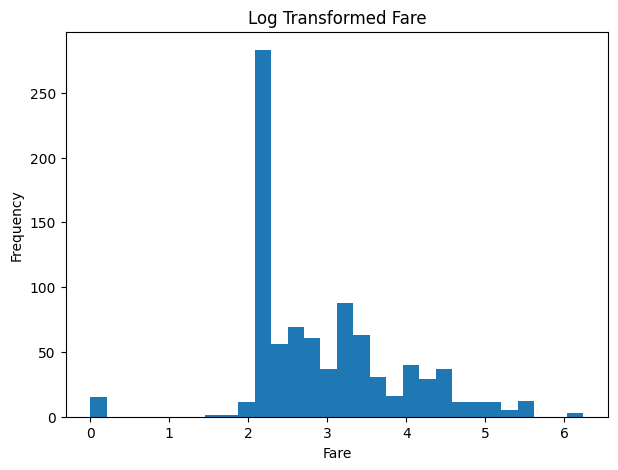

In [8]:
plt.figure(figsize=(7,5))

plt.hist(df["Fare_Log"], bins=30)

plt.title("Log Transformed Fare")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.show()

## 📌 Square Root Transformation

Square Root Transformation is useful for moderately skewed data.

Formula:

√x

In [9]:
df["Fare_Sqrt"] = np.sqrt(df["Fare"])

df[["Fare","Fare_Sqrt"]].head()

,Fare,Fare_Sqrt
0,7.2500,2.692582
1,71.2833,8.442944
2,7.9250,2.815138
3,53.1000,7.286975
4,8.0500,2.837252


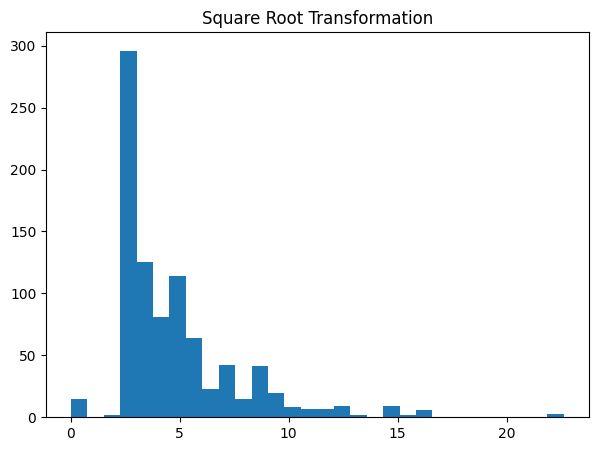

In [10]:
plt.figure(figsize=(7,5))

plt.hist(df["Fare_Sqrt"], bins=30)

plt.title("Square Root Transformation")

plt.show()

## 📌 Reciprocal Transformation

Reciprocal Transformation is useful for reducing the effect of large values.

Formula:

1/x

It should not be used when values contain zeros.

In [15]:
df["Fare_Reciprocal"] = 1/(df["Fare"]+1)

df[["Fare","Fare_Reciprocal"]].head()

,Fare,Fare_Reciprocal
0,7.2500,0.121212
1,71.2833,0.013834
2,7.9250,0.112045
3,53.1000,0.018484
4,8.0500,0.110497


## 📌 Box-Cox Transformation

Box-Cox Transformation automatically finds the best power transformation.

Requirements:

- Data must be positive.

In [14]:
boxcox = PowerTransformer(method="box-cox")

df["Fare_BoxCox"] = boxcox.fit_transform(df[["Fare"]])

df[["Fare","Fare_BoxCox"]].head()

ValueError: The Box-Cox transformation can only be applied to strictly positive data

## 📌 Yeo-Johnson Transformation

Yeo-Johnson is similar to Box-Cox.

Advantages:

- Works with positive values.
- Works with zero values.
- Works with negative values.

In [16]:
yeojohnson = PowerTransformer(method="yeo-johnson")

df["Fare_Yeo"] = yeojohnson.fit_transform(df[["Fare"]])

df[["Fare","Fare_Yeo"]].head()

,Fare,Fare_Yeo
0,7.2500,-0.878820
1,71.2833,1.336651
2,7.9250,-0.790065
3,53.1000,1.067352
4,8.0500,-0.774439


In [18]:
df[[
    "Fare",
    "Fare_Log",
    "Fare_Sqrt",
    "Fare_Yeo"
]].head()

,Fare,Fare_Log,Fare_Sqrt,Fare_Yeo
0,7.2500,2.110213,2.692582,-0.878820
1,71.2833,4.280593,8.442944,1.336651
2,7.9250,2.188856,2.815138,-0.790065
3,53.1000,3.990834,7.286975,1.067352
4,8.0500,2.202765,2.837252,-0.774439


📌 When to Use Which Transformation?

| Transformation | Best For                          |
| -------------- | --------------------------------- |
| Log            | Highly right-skewed positive data |
| Square Root    | Moderately skewed data            |
| Reciprocal     | Very large outliers               |
| Box-Cox        | Positive numerical data           |
| Yeo-Johnson    | Data with zero or negative values |


## 🌍 Applications

Feature Transformation is widely used in:

- House Price Prediction
- Stock Market Analysis
- Medical Data
- Income Prediction
- Customer Spending Analysis

## 🔍 Observations

- Feature Transformation changes the distribution of data.
- Log Transformation is one of the most commonly used techniques.
- Box-Cox and Yeo-Johnson automatically find suitable transformations.
- Choosing the right transformation depends on the data distribution.

## ✅ Best Practices

- Visualize data before choosing a transformation.
- Avoid applying Log Transformation to negative values.
- Use Box-Cox only for positive data.
- Use Yeo-Johnson when data contains zero or negative values.
- Evaluate whether the transformation improves model performance.

## 🌍 Real-World Scenario

An e-commerce company analyzes customer spending. A few customers spend extremely large amounts, making the data highly skewed. Applying a Log Transformation reduces skewness, allowing the machine learning model to better capture patterns in customer behavior.

## 📝 Summary

In this notebook, we learned about Feature Transformation, explored common transformation techniques such as Log, Square Root, Reciprocal, Box-Cox, and Yeo-Johnson, and applied them to the Titanic dataset to understand how they change feature distributions.